<a href="https://colab.research.google.com/github/YoursTruly-02/Robust-Phishing-and-Homoglyph-Detection-Engine/blob/main/Robust_Phishing_and_Homoglyph_Detection_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("victusadi/phishing-urls-dataset-with-extracted-features")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'phishing-urls-dataset-with-extracted-features' dataset.
Path to dataset files: /kaggle/input/phishing-urls-dataset-with-extracted-features


In [111]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

import gradio as gr

In [112]:
#Locating

# 1. find the exact file name
files = os.listdir(path)
print("Files in downloaded folder:", files)

# 2.grab the first CSV file in the folder
csv_filename = [f for f in files if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

# 3. Load the data into a Pandas DataFrame
df = pd.read_csv(full_file_path)

df.head()

Files in downloaded folder: ['phishing_features.csv']


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [113]:
#missing data check
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")
# missing values for every column
print(df.isnull().sum())

Total missing values in the dataset: 821
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160064 entries, 0 to 160063
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 160064 non-null  object 
 1   label               160064 non-null  int64  
 2   url_length          160064 non-null  int64  
 3   num_dots            160064 non-null  int64  
 4   has_https           160064 non-null  int64  
 5   has_ip              160064 non-null  int64  
 6   num_subdirs         160064 non-null  int64  
 7   num_params          160064 non-null  int64  
 8   suspicious_words    160064 non-null  int64  
 9   tld                 159243 non-null  object 
 10  special_char_count  160064 non-null  int64  
 11  digits_count        160064 non-null  int64  
 12  entropy             160064 non-null  float64
dtypes: float64(1), int64(10), object(2)
memory usage: 15.9+ MB


In [115]:
df.describe()

,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy
count,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000,160064.000000
mean,0.994877,55.107382,2.998963,0.434089,0.485475,4.128436,0.221499,0.023809,1.495446,12.737036,4.246100
std,0.071391,101.782469,1.119210,0.495638,0.499791,2.090180,0.935608,0.168235,3.699627,17.420579,0.479275
min,0.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.058814
25%,1.000000,30.000000,2.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,3.907734
50%,1.000000,37.000000,3.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,12.000000,4.171465
75%,1.000000,65.000000,4.000000,1.000000,1.000000,4.000000,0.000000,0.000000,1.000000,16.000000,4.484850
max,1.000000,25523.000000,59.000000,1.000000,1.000000,104.000000,45.000000,3.000000,264.000000,3413.000000,6.030422


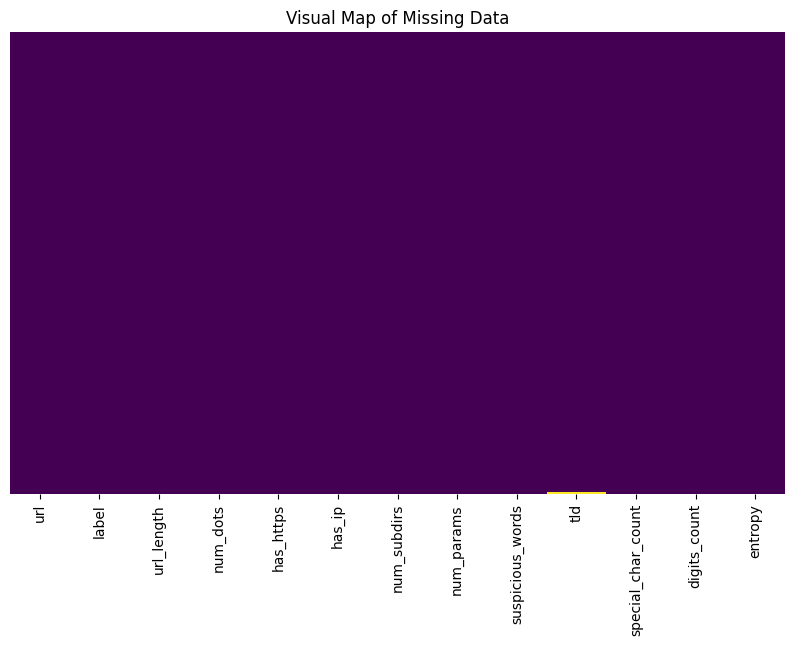

In [116]:
plt.figure(figsize=(10, 6))
# cbar=False turns off the color legend, yticklabels=False hides row numbers for speed
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visual Map of Missing Data")
plt.show()

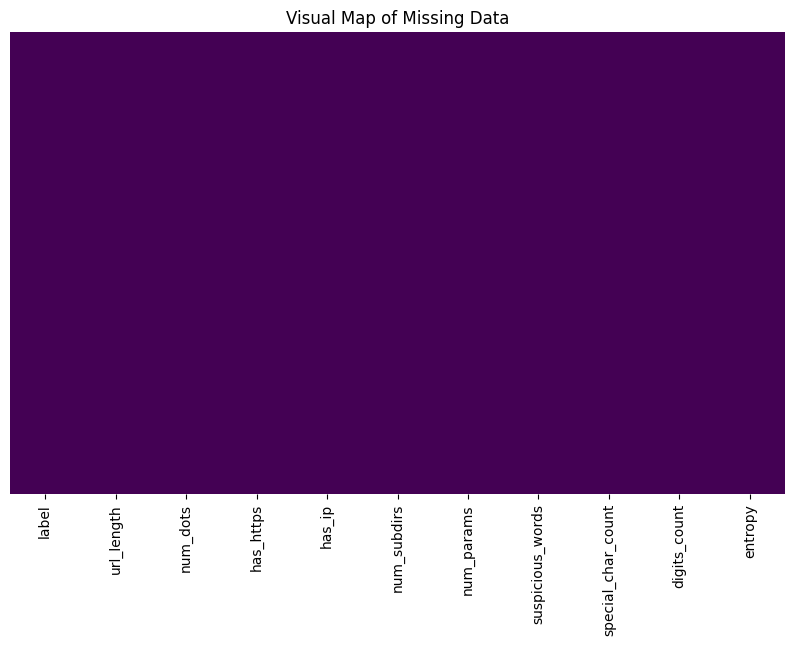

In [117]:
df1 = df.drop(columns=['url','tld'])


plt.figure(figsize=(10, 6))
# cbar=False turns off the color legend, yticklabels=False hides row numbers for speed
sns.heatmap(df1.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visual Map of Missing Data")
plt.show()

In [118]:
df1.head()

,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy
0,1,89,3,0,0,5,0,2,4,29,4.792985
1,1,25,1,0,0,4,0,0,0,7,4.003856
2,1,30,1,0,0,4,0,0,0,7,4.053236
3,1,39,2,1,0,3,0,0,3,0,4.150411
4,1,37,2,1,0,3,0,0,0,0,4.100817


In [119]:
#split data

X = df1.drop(columns=['label','num_subdirs','has_ip','num_params','suspicious_words'])
y = df1['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [120]:
#model1
lr_model= LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train, y_train)



LogisticRegression(max_iter=1000, random_state=42)

In [121]:
#result
y_pred1 = lr_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred1)
print(cm)
print(classification_report(y_test,y_pred1))
accuracy_score(y_test,y_pred1)
# recall_score(y_test, y_pred1)

[[  159     5]
 [   11 31838]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       0.97      0.98      0.98     32013
weighted avg       1.00      1.00      1.00     32013



0.999500203042514

In [122]:
#feature imp chart

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': lr_model.coef_[0]
})

# Sort them to see the most influential features at the top and bottom
feature_importance = feature_importance.sort_values(by='Weight', ascending=False)

print("--- Features strongly predicting Class 1 ---")
print(feature_importance.head(5))

print("\n--- Features strongly predicting Class 0 ---")
print(feature_importance.tail(5))

--- Features strongly predicting Class 1 ---
              Feature    Weight
2           has_https  4.439471
3  special_char_count  2.037441
1            num_dots  1.820198
0          url_length  1.385658
4        digits_count -0.414064

--- Features strongly predicting Class 0 ---
              Feature    Weight
3  special_char_count  2.037441
1            num_dots  1.820198
0          url_length  1.385658
4        digits_count -0.414064
5             entropy -6.360240


In [123]:
#feature scaling model1

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model_scaled = LogisticRegression(random_state=42, max_iter=1000)
lr_model_scaled.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [124]:
y_pred_scaled = lr_model_scaled.predict(X_test_scaled)
cm=confusion_matrix(y_test,y_pred_scaled)
print(cm)
print(classification_report(y_test,y_pred_scaled))
accuracy_score(y_test,y_pred_scaled)

[[  127    37]
 [   20 31829]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.82       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       0.93      0.89      0.91     32013
weighted avg       1.00      1.00      1.00     32013



0.998219473338956

In [125]:
#feature imp chart

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': lr_model_scaled.coef_[0]
})

# Sort them to see the most influential features at the top and bottom
feature_importance = feature_importance.sort_values(by='Weight', ascending=False)

print("--- Features strongly predicting Class 1 ---")
print(feature_importance.head(5))

print("\n--- Features strongly predicting Class 0 ---")
print(feature_importance.tail(5))

--- Features strongly predicting Class 1 ---
              Feature    Weight
0          url_length  9.013083
1            num_dots  5.763962
2           has_https  5.143891
5             entropy  2.451590
3  special_char_count  2.394076

--- Features strongly predicting Class 0 ---
              Feature    Weight
1            num_dots  5.763962
2           has_https  5.143891
5             entropy  2.451590
3  special_char_count  2.394076
4        digits_count -0.325729


In [126]:
#model2
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,max_features="sqrt")

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [127]:
y_pred2 = rf_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred2)
print(cm)
print(classification_report(y_test,y_pred2))
accuracy_score(y_test,y_pred2)

[[  157     7]
 [    7 31842]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       0.98      0.98      0.98     32013
weighted avg       1.00      1.00      1.00     32013



0.9995626776621998

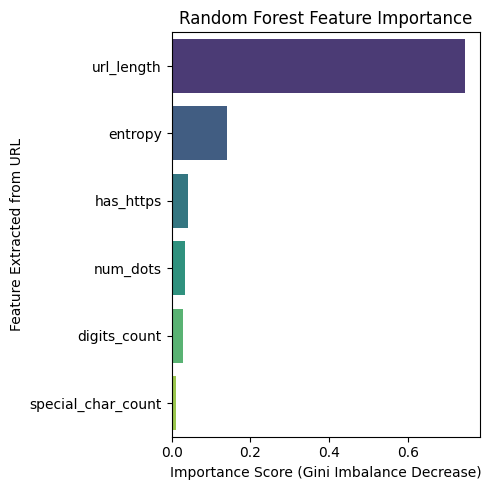

In [128]:
importances = rf_model.feature_importances_

feature_names = X_train.columns
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort them from highest to lowest
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(5, 5))
sns.barplot(data=rf_importance_df, y='Feature', x='Importance', palette='viridis', hue='Feature', legend=False)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score (Gini Imbalance Decrease)")
plt.ylabel("Feature Extracted from URL")
plt.tight_layout()
plt.show()

In [129]:
#model3

xgb_model=XGBClassifier( eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [130]:
y_pred3 = xgb_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred3)
print(cm)
print(classification_report(y_test,y_pred3))
accuracy_score(y_test,y_pred3)


[[  123    41]
 [   28 31821]]
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       164
           1       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       0.91      0.87      0.89     32013
weighted avg       1.00      1.00      1.00     32013



0.9978446256208415

**Model saving**

In [131]:
import joblib


joblib.dump(xgb_model, 'phishing_xgboost_engine.pkl')



['phishing_xgboost_engine.pkl']